# Tutorial: order parameters on reference structures

Four deliberately constructed on-lattice anion configurations for a
`12 x 12 x 12` MX3 supercell, with each of the five `chainorder` order
parameters applied and the output compared to the expected signature of
each structure. All four structures are at XO2F stoichiometry (1/3 F).

See `docs/concepts.md` for the conceptual background on the data model
and each order parameter; this notebook assumes that material.

Dependencies beyond `chainorder`: `numpy`, `matplotlib`, `ase`.


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from ase import Atoms

from chainorder import SublatticeOccupation, order_params

N = 12            # supercell size (cubic)
a = 3.9           # lattice parameter, angstrom (arbitrary for on-lattice analysis)
rng = np.random.default_rng(0)

# Grid indices, shared by all structure builders.
ii, jj, kk = np.meshgrid(np.arange(N), np.arange(N), np.arange(N), indexing="ij")


A small helper builds an ASE `Atoms` object from three per-direction
occupation arrays. `ox[i, j, k] == 1` places F at the x-edge midpoint
`(i + 1/2, j, k) * a`; similarly for `oy` (at `(i, j + 1/2, k) * a`)
and `oz` (at `(i, j, k + 1/2) * a`). `0` entries are O.


In [2]:
def build_atoms(ox, oy, oz, N=N, a=a, cation="Nb"):
    '''Build an on-lattice MX3 ASE Atoms from three per-direction occupations.'''
    cat_pos = np.stack([ii, jj, kk], axis=-1).reshape(-1, 3).astype(float) * a
    cat_sym = [cation] * (N ** 3)

    x_pos = np.stack([ii + 0.5, jj, kk], axis=-1).reshape(-1, 3) * a
    x_sym = np.where(ox.astype(bool), "F", "O").reshape(-1).tolist()

    y_pos = np.stack([ii, jj + 0.5, kk], axis=-1).reshape(-1, 3) * a
    y_sym = np.where(oy.astype(bool), "F", "O").reshape(-1).tolist()

    z_pos = np.stack([ii, jj, kk + 0.5], axis=-1).reshape(-1, 3) * a
    z_sym = np.where(oz.astype(bool), "F", "O").reshape(-1).tolist()

    positions = np.concatenate([cat_pos, x_pos, y_pos, z_pos])
    symbols = cat_sym + x_sym + y_sym + z_sym
    return Atoms(
        symbols=symbols,
        positions=positions,
        cell=np.diag([N * a, N * a, N * a]),
        pbc=True,
    )


## Reference structures


### 1. Random

Each anion site is F independently with probability 1/3. No ordering:
a high-temperature MC snapshot in miniature.


In [3]:
p_F = 1 / 3
ox = (rng.random((N, N, N)) < p_F).astype(int)
oy = (rng.random((N, N, N)) < p_F).astype(int)
oz = (rng.random((N, N, N)) < p_F).astype(int)
atoms_random = build_atoms(ox, oy, oz)
print(f"F fraction: {(ox.sum() + oy.sum() + oz.sum()) / (3 * N ** 3):.3f}")


F fraction: 0.330


### 2. OOF chains, phases coupled for uniform cis coordination

Period-3 F (one F per three sites) on each chain in each direction, with
inter-chain phases chosen so that every cation has exactly 2 F
neighbours sitting on two different axes (i.e. cis). The phase rule is:

- x-chain at lateral `(j, k)`: F at `i = (j + k) mod 3`.
- y-chain at lateral `(i, k)`: F at `j = (i - k) mod 3`.
- z-chain at lateral `(i, j)`: F at `k = (i - j + 1) mod 3`.

(Other phase relationships give OOF on each chain but different cis/trans
coordination patterns; structure 3 below uses uncorrelated phases.)


In [4]:
ox = ((ii % 3) == ((jj + kk) % 3)).astype(int)
oy = ((jj % 3) == ((ii - kk) % 3)).astype(int)
oz = ((kk % 3) == ((ii - jj + 1) % 3)).astype(int)
atoms_oof_correlated = build_atoms(ox, oy, oz)
print(f"F fraction: {(ox.sum() + oy.sum() + oz.sum()) / (3 * N ** 3):.3f}")


F fraction: 0.333


### 3. OOF chains with uncorrelated phases

Each chain still has period-3 F, but the phase of each chain is chosen
independently at random. The chains are individually ordered but their
period-3 patterns are uncorrelated with each other.


In [5]:
rng_phases = np.random.default_rng(1)
px = rng_phases.integers(0, 3, size=(N, N))   # phase of x-chain at (j, k)
py = rng_phases.integers(0, 3, size=(N, N))   # phase of y-chain at (i, k)
pz = rng_phases.integers(0, 3, size=(N, N))   # phase of z-chain at (i, j)

ox = ((ii % 3) == px[jj, kk]).astype(int)
oy = ((jj % 3) == py[ii, kk]).astype(int)
oz = ((kk % 3) == pz[ii, jj]).astype(int)
atoms_oof_uncorrelated = build_atoms(ox, oy, oz)
print(f"F fraction: {(ox.sum() + oy.sum() + oz.sum()) / (3 * N ** 3):.3f}")


F fraction: 0.333


### 4. Period-2 on x and y, all-O on z (different ordering topology)

Alternating `OFOF...` along x and y-oriented chains, but no F at all on
the z-sublattice. Each cation ends up with exactly 2 F, one from the
x-axis and one from the y-axis — again cis, but with different chain
periodicity from structure 2.


In [6]:
ox = ((ii % 2) == 1).astype(int)
oy = ((jj % 2) == 1).astype(int)
oz = np.zeros((N, N, N), dtype=int)
atoms_ofof = build_atoms(ox, oy, oz)
print(f"F fraction: {(ox.sum() + oy.sum() + oz.sum()) / (3 * N ** 3):.3f}")


F fraction: 0.333


### Build `SublatticeOccupation`s

Each ASE `Atoms` is passed to `SublatticeOccupation.from_atoms` to
produce the data structure the order parameters consume.


In [7]:
structures = {
    "random":         SublatticeOccupation.from_atoms(atoms_random,      N=N, species="F"),
    "OOF-correlated":        SublatticeOccupation.from_atoms(atoms_oof_correlated,      N=N, species="F"),
    "OOF-uncorrelated":   SublatticeOccupation.from_atoms(atoms_oof_uncorrelated, N=N, species="F"),
    "OFOF":           SublatticeOccupation.from_atoms(atoms_ofof,        N=N, species="F"),
}
labels = list(structures.keys())
colors = {"random": "#888888", "OOF-correlated": "#1f77b4", "OOF-uncorrelated": "#ff7f0e", "OFOF": "#2ca02c"}


## `chain_fft`: per-chain Fourier spectrum


For each chain, `chain_fft` returns the DFT of its species sequence.
We plot the mean `|F(k)|^2` across all chains of one direction, per
structure.

Expected signatures:

- **random**: flat noise floor, no peaks.
- **OOF-correlated** and **OOF-uncorrelated**: peaks at `k = 0, N/3, 2 N/3` for
  each direction (period-3 chains). Equal in both structures — phase
  correlations between chains don't affect per-chain amplitude.
- **OFOF**: peaks at `k = 0` and `k = N/2` for x and y directions
  (period-2). Zero spectrum for z (uniformly O).


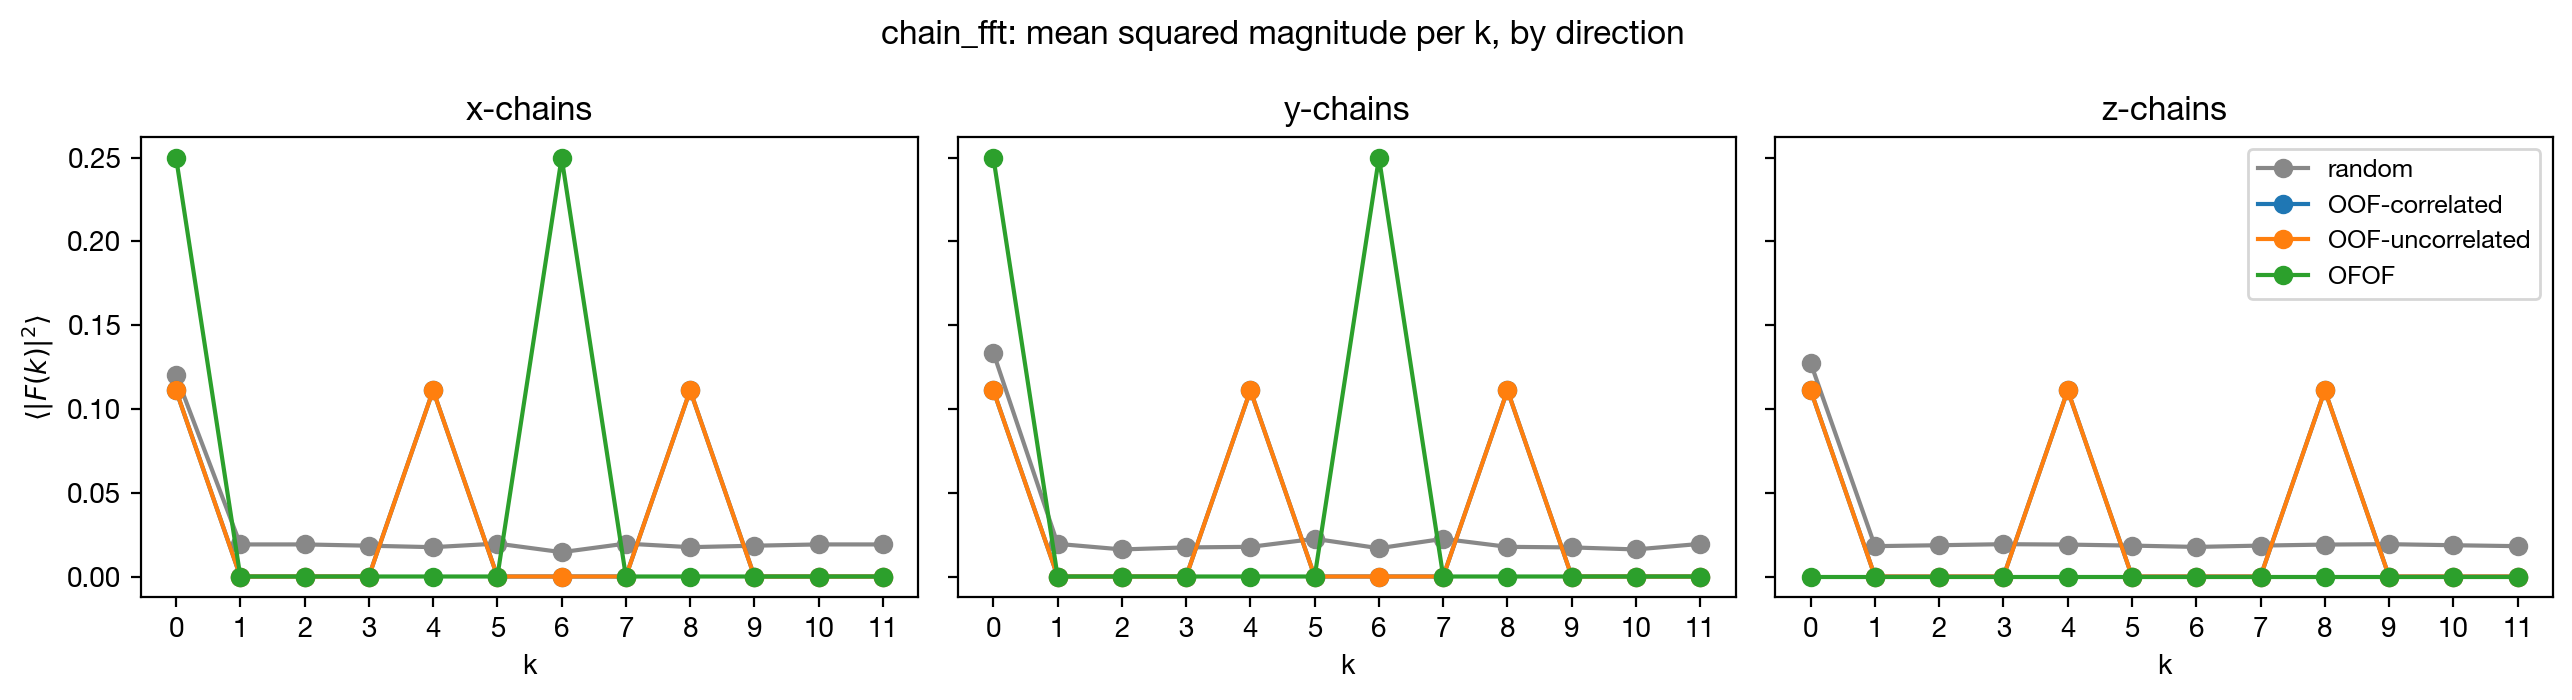

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, direction, view_attr in zip(axes, "xyz", ("x", "y", "z")):
    ax.set_title(f"{direction}-chains")
    ax.set_xlabel("k")
    for name in labels:
        view = getattr(structures[name], view_attr)
        spectrum = np.abs(order_params.chain_fft(view)) ** 2      # (lat0, lat1, N)
        mean_spectrum = spectrum.mean(axis=(0, 1))
        ax.plot(np.arange(N), mean_spectrum, marker="o", label=name, color=colors[name])
    ax.set_xticks(np.arange(N))
axes[0].set_ylabel(r"$\langle |F(k)|^2 \rangle$")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle("chain_fft: mean squared magnitude per k, by direction")
fig.tight_layout()
plt.show()


The period-3 peaks for **OOF-correlated** and **OOF-uncorrelated** sit at
`k = 4` and `k = 8` (= `N/3` and `2 N/3` for `N = 12`); the period-2
peak for **OFOF** sits at `k = 6` (= `N/2`). The **random** trace
hovers near the noise floor everywhere except `k = 0`. The z-panel
for **OFOF** is flat at zero — its z-chains contain no F.


## `along_chain_correlation`: along-chain pair correlation $g(r)$


Expected signatures:

- **random**: `g(0)` positive, `g(r) ~ 0` for `r > 0`.
- **OOF-correlated** and **OOF-uncorrelated**: `g(r) = 2/9` at
  `r = 0, 3, 6, 9`; `g(r) = -1/9` at `r = 1, 2, 4, 5, 7, 8, 10, 11`.
  Identical between the two -- per-chain correlations are unaffected
  by inter-chain phases.
- **OFOF**: `g(r) = 1/4` at even `r`, `g(r) = -1/4` at odd `r` for
  x and y directions; all zeros for z (the z-chains are constant, so
  their variance and all their pair correlations are zero).


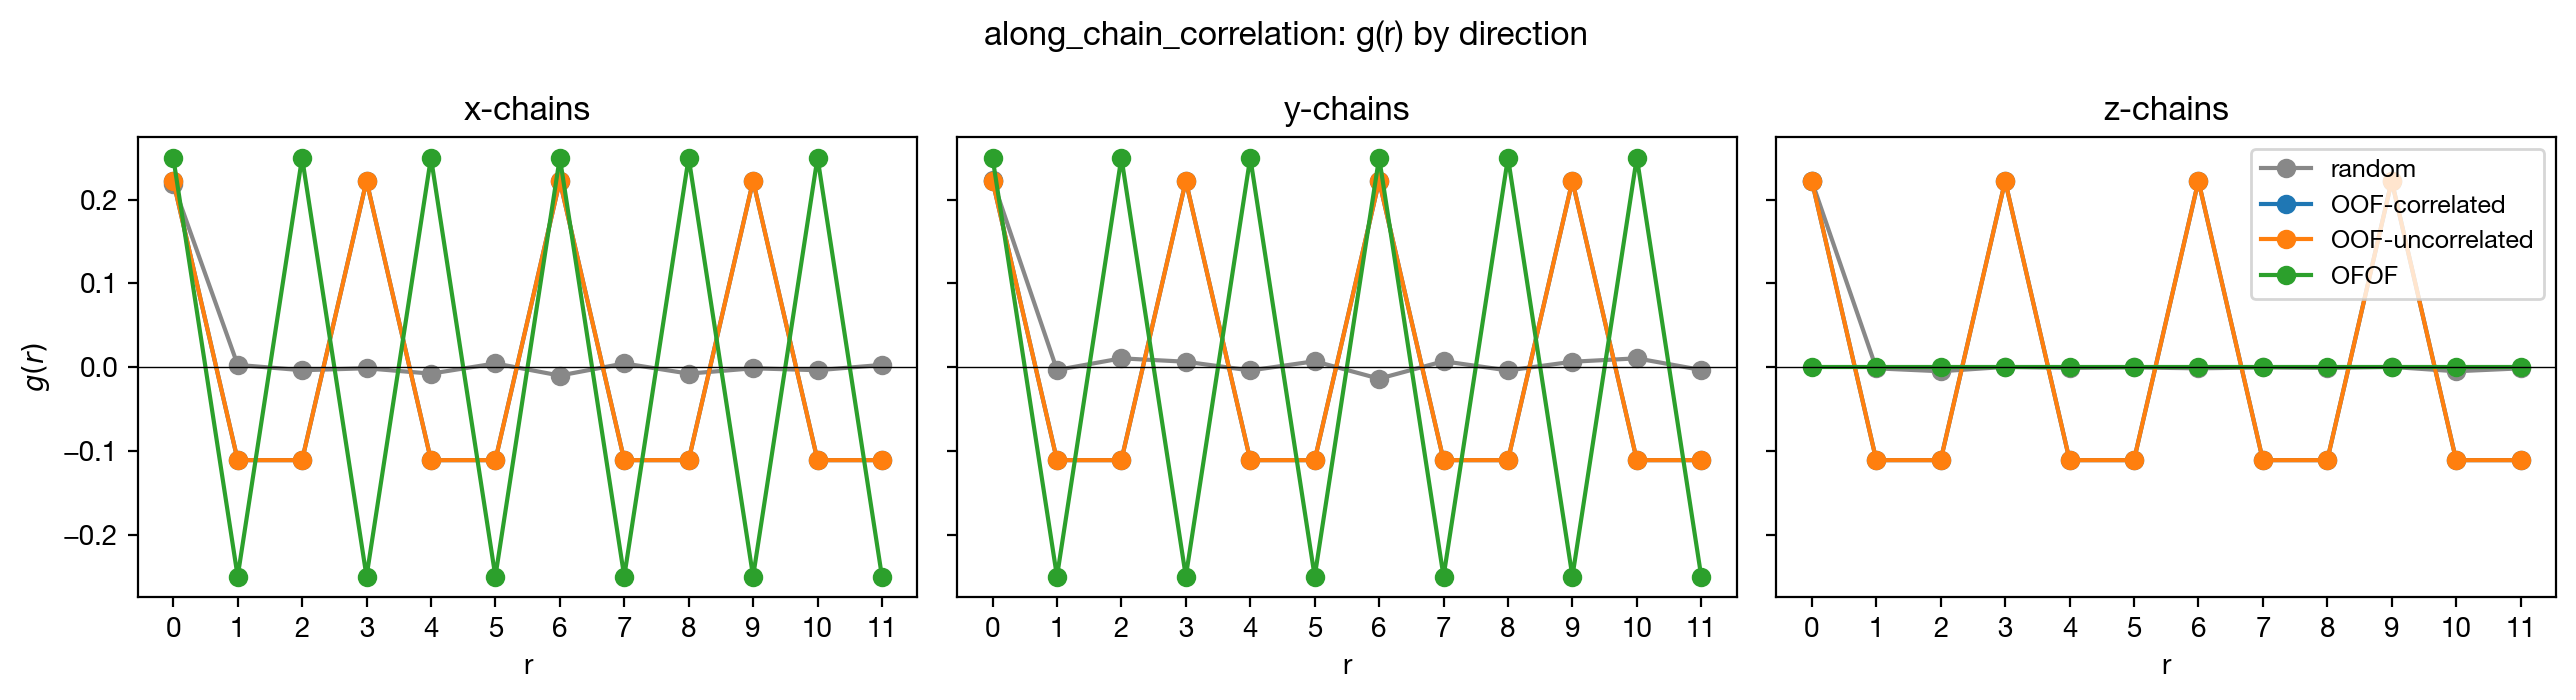

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, direction, view_attr in zip(axes, "xyz", ("x", "y", "z")):
    ax.set_title(f"{direction}-chains")
    ax.set_xlabel("r")
    for name in labels:
        view = getattr(structures[name], view_attr)
        g = order_params.along_chain_correlation(view)
        ax.plot(np.arange(N), g, marker="o", label=name, color=colors[name])
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xticks(np.arange(N))
axes[0].set_ylabel(r"$g(r)$")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle("along_chain_correlation: g(r) by direction")
fig.tight_layout()
plt.show()


For **OFOF** the z-panel is flat at zero because every z-chain is
uniformly O: the species flag is constant, so its variance (which is
`g(0)`) is zero, and so are the lagged correlations.


## `motif_frequencies`: local motif frequencies


`motif_frequencies` slides a window of length `window_length` along
each chain and returns the fraction of windows matching each
distinct bit pattern, per chain. With `window_length = 3` the
possible patterns are the eight length-3 bit tuples from
`(0, 0, 0) = OOO` to `(1, 1, 1) = FFF`.

Expected per-motif frequencies (averaged over all chains of one
direction):

- **OOF-correlated** and **OOF-uncorrelated**: each chain has
  period-3 ordering, so the sliding window produces three distinct
  motifs as it steps through the three phases — `OOF`, `OFO`,
  `FOO` — each at frequency `1/3`.
- **OFOF**: x- and y-chains have period-2 alternation; the sliding
  window produces `OFO` and `FOF`, each at frequency `1/2`. The
  z-chains are uniformly O, producing only `OOO` at frequency `1`.
- **random**: spreads frequency across all eight motifs, heaviest on
  O-rich patterns and lightest on F-rich patterns.


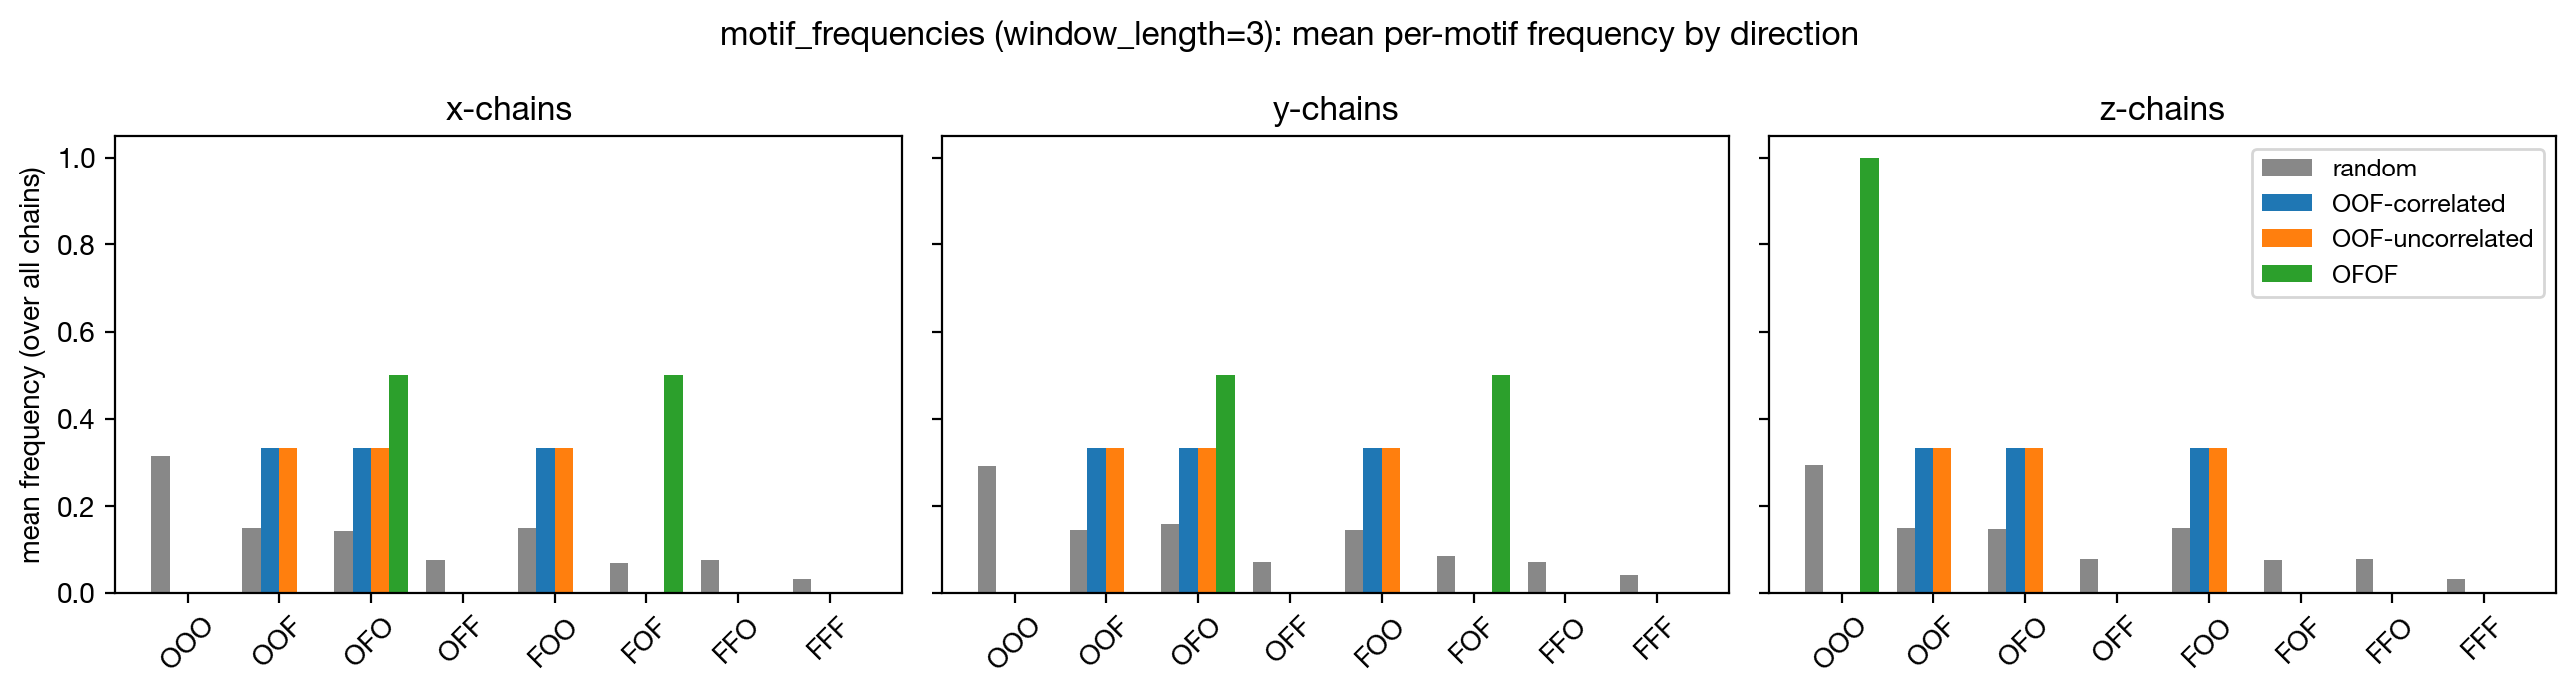

In [10]:
w = 3
all_motifs = {
    (0, 0, 0): "OOO",
    (0, 0, 1): "OOF",
    (0, 1, 0): "OFO",
    (0, 1, 1): "OFF",
    (1, 0, 0): "FOO",
    (1, 0, 1): "FOF",
    (1, 1, 0): "FFO",
    (1, 1, 1): "FFF",
}
motif_order = list(all_motifs.keys())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, direction, view_attr in zip(axes, "xyz", ("x", "y", "z")):
    ax.set_title(f"{direction}-chains")
    x_positions = np.arange(len(motif_order))
    bar_width = 0.2
    for i, name in enumerate(labels):
        view = getattr(structures[name], view_attr)
        freqs = order_params.motif_frequencies(view, window_length=w)
        # Mean across all chains of the direction (lateral plane).
        means = [freqs.get(m, np.zeros((view.shape[0], view.shape[1]))).mean()
                 for m in motif_order]
        ax.bar(x_positions + i * bar_width - 1.5 * bar_width, means,
               width=bar_width, label=name, color=colors[name])
    ax.set_xticks(x_positions)
    ax.set_xticklabels([all_motifs[m] for m in motif_order], rotation=45)
axes[0].set_ylabel("mean frequency (over all chains)")
axes[-1].legend(loc="upper right", fontsize=9)
fig.suptitle("motif_frequencies (window_length=3): mean per-motif frequency by direction")
fig.tight_layout()
plt.show()


The **OOF-correlated** and **OOF-uncorrelated** bars are identical
in all three directions: each puts equal frequency `1/3` on `OOF`,
`OFO`, and `FOO` — the three length-3 windows a period-3 chain
produces as it slides through its three phases. **OFOF** puts
frequency `1/2` on `OFO` and `FOF` in x- and y-directions; its
z-bar is entirely on `OOO` at frequency `1`. **random** spreads
frequency across all eight motifs, `OOO` largest and `FFF`
smallest.


## `inter_chain_correlation`: lateral coherence of a chain harmonic


Computed on `occ.x` at `period=3`. Expected:

- **OOF-correlated**: the phase rule `px(j, k) = (j + k) mod 3` gives `|G| ~ 1`
  for all lateral lags, with a linear phase gradient along both
  lateral directions.
- **OOF-uncorrelated**: each x-chain has a random period-3 phase, so
  `|G| ~ 0` off the origin.
- **random**: raises — no coherent period-3 amplitude on each chain
  (some chains may have zero weight, but others have noise-level
  amplitudes; the normalisation is still well-defined, so we handle
  the potential error and skip plotting if it fires).
- **OFOF**: raises — the x-chains are period-2, so `|phi|^2 = 0` at
  the period-3 harmonic and the correlation is undefined. We catch
  this and skip.


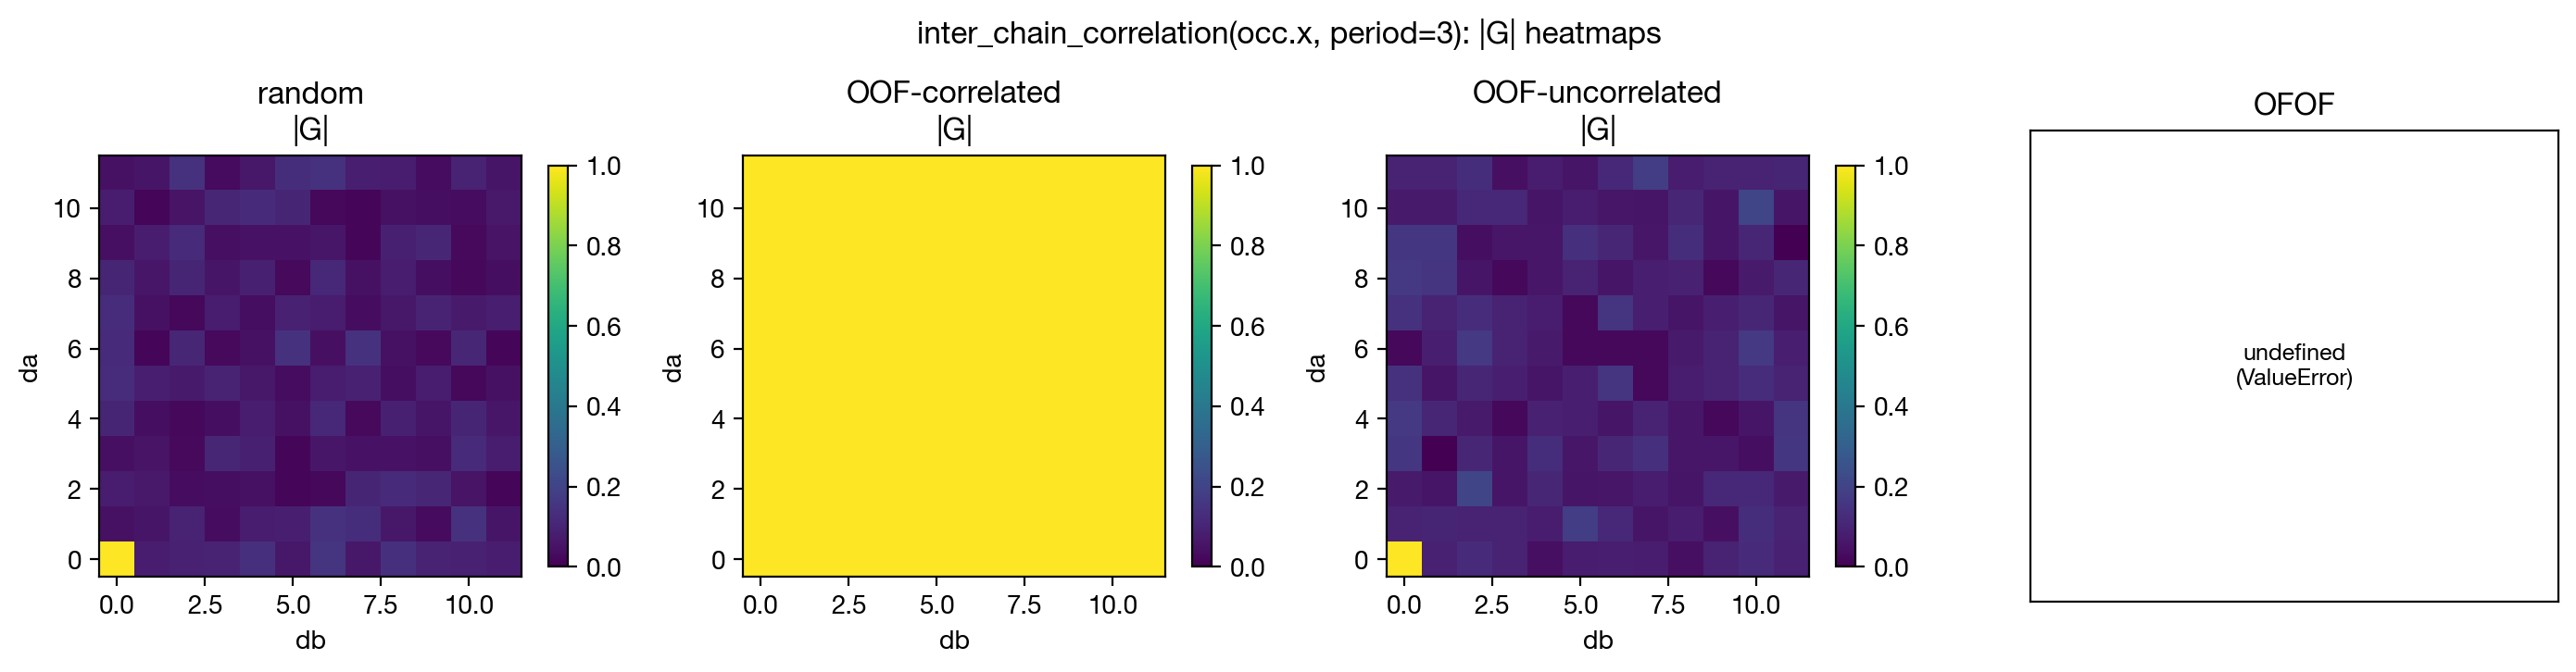

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, name in zip(axes, labels):
    view = structures[name].x
    try:
        G = order_params.inter_chain_correlation(view, period=3)
        im = ax.imshow(np.abs(G), vmin=0, vmax=1, origin="lower", cmap="viridis")
        ax.set_title(f"{name}\n|G|")
        ax.set_xlabel("db")
        ax.set_ylabel("da")
        fig.colorbar(im, ax=ax, shrink=0.85)
    except ValueError as e:
        ax.text(0.5, 0.5, f"undefined\n({type(e).__name__})",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=9)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle("inter_chain_correlation(occ.x, period=3): |G| heatmaps")
fig.tight_layout()
plt.show()


**OOF-correlated** and **OOF-uncorrelated** gave identical outputs in
`chain_fft`, `along_chain_correlation`, and `motif_frequencies` — the
per-chain observables are blind to the phase relationships *between*
chains. `inter_chain_correlation` is the smallest-data observable
that separates them: **OOF-correlated**'s `|G| = 1` across the whole lateral
plane reflects the deterministic phase rule `(j + k) mod 3` (every
chain pair differs by a fixed phase offset, so the amplitude-weighted
correlation is perfectly coherent), while **OOF-uncorrelated**'s `|G|`
drops off the origin as the random per-chain phases average to noise.

**OFOF** fails the "non-zero amplitude at the chosen harmonic"
requirement: its x-chains are period-2, so the period-3 Fourier
coefficient is zero on every chain.


## `structure_factor`: 3D diffuse-scattering intensity


`structure_factor(occ)` returns `|F(kx, ky, kz)|^2` on the full
`12 x 12 x 12` reciprocal-lattice grid — 1728 values per structure.
To look at this as a 2D image we have to collapse one axis; we do
this with a **max projection**. "Max over `kz`" means: at each
`(kx, ky)` point of the resulting 2D plot, take the largest
`|F|^2` found anywhere along the collapsed `kz` axis. (Max rather
than mean, because we want bright peaks to survive even if they
sit off `kz = 0`.) "Max over `ky`" and "max over `kx`" are the
analogous collapses of the other two axes.

Each row of the figure below shows the three max projections for
one structure.


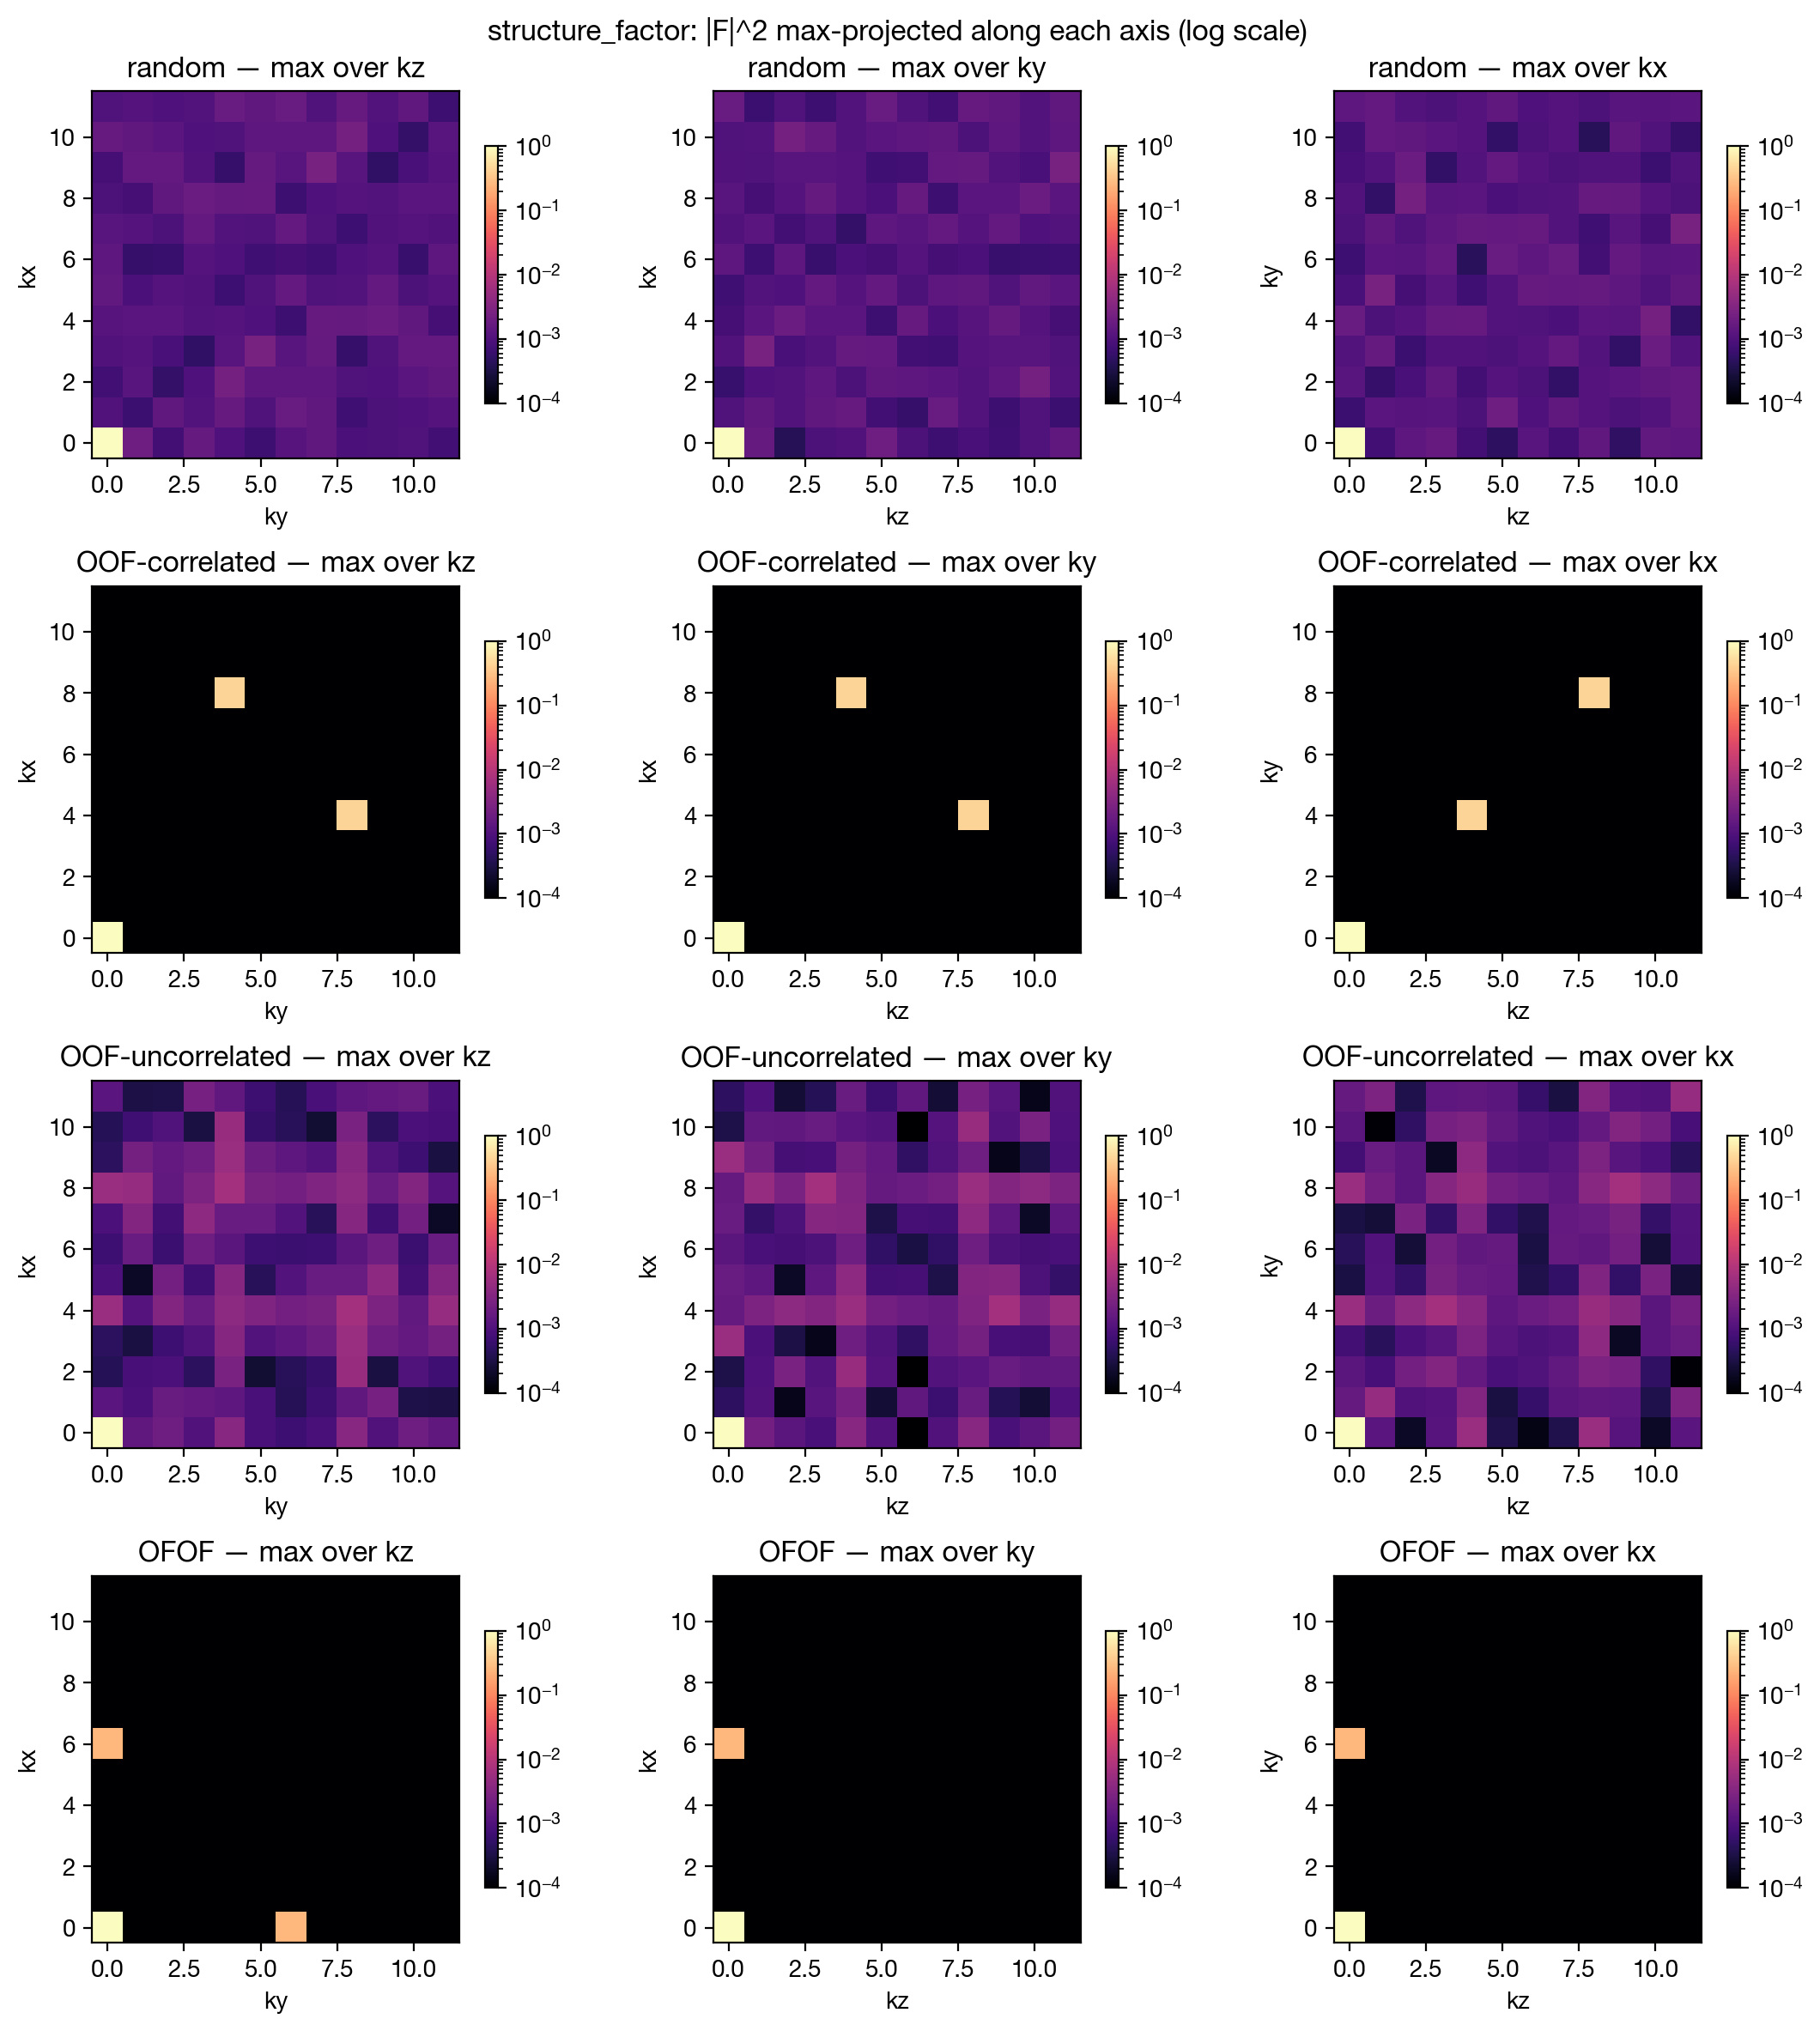

In [12]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(len(labels), 3, figsize=(11, 3 * len(labels)))
proj_names = [
    ("max over kz", "kx", "ky"),
    ("max over ky", "kx", "kz"),
    ("max over kx", "ky", "kz"),
]
norm = LogNorm(vmin=1e-4, vmax=1, clip=True)
for i, name in enumerate(labels):
    F = order_params.structure_factor(structures[name])       # (Nx, Ny, Nz)
    intensity = np.abs(F) ** 2
    projections = [intensity.max(axis=2), intensity.max(axis=1), intensity.max(axis=0)]
    for j, (proj_label, x_label, y_label) in enumerate(proj_names):
        ax = axes[i, j]
        im = ax.imshow(projections[j], origin="lower", cmap="magma", norm=norm)
        ax.set_title(f"{name} — {proj_label}")
        ax.set_xlabel(y_label)
        ax.set_ylabel(x_label)
        fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("structure_factor: |F|^2 max-projected along each axis (log scale)")
fig.tight_layout()
plt.show()


**random**: a disordered occupation has no coherent periodic
component. The only peak is at the origin `k = (0, 0, 0)`, and its
value is the mean F fraction — it's always there for any non-empty
occupation and tells you nothing about ordering. Everywhere else the
FFT is noise-level. All three projections look alike: one bright
corner on a dim noisy background.

**OOF-correlated**: perfectly ordered. The 3D FFT has exactly three
peaks: the DC one at `(0, 0, 0)`, and two off-axis peaks at
`(8, 4, 4)` and `(4, 8, 8)`. Notice that `ky = kz` in both off-axis
peaks, while `kx` differs (`4` vs `8`). Collapsing `kx` with a max
projection therefore drops both peaks onto the `ky = kz` line --
the *main* diagonal at `(4, 4)` and `(8, 8)`. Collapsing `ky` or
`kz` instead leaves `kx` as one axis of the 2D panel and one of
`(ky, kz)` as the other, giving distinct coordinates: the peaks
land on the *anti-*diagonal at `(4, 8)` and `(8, 4)`. That's why
the `max over kx` panel looks different from the other two.

**OOF-uncorrelated**: each chain has period-3 ordering on its own, but
the phase of each chain is random. Consider the x-sublattice on its
own. Period-3 along each chain forces `F_x` to be zero unless `kx`
is a period-3 harmonic (`kx = 0, 4, 8`). But because the chain
phases are random, the FFT amplitude at each of those `kx` values
spreads noise-like across all `(ky, kz)` — the lateral plane of
the chains. The non-zero intensity therefore fills whole *lines*
through k-space at fixed `kx = 4` and `kx = 8`. These lines are
often called **rods**. The y- and z-sublattices give analogous
rods along their own axes. A max projection collapses each rod
into a *row* of intensity in the 2D panel at the period-3 k-value.

**OFOF**: period-2 along x and y, all-O on z. Period-2 along the
x-chain gives an FFT peak at `kx = 6` (where `6 = N/2`), and since
the x-sublattice is uniform across the other two directions that
peak sits exactly on the `kx` axis at `(6, 0, 0)` (no smearing in
`ky, kz`). The y-sublattice contributes a matching peak at
`(0, 6, 0)`. The z-sublattice is empty, contributing nothing
anywhere but the DC point. So the `max over kz` panel shows three
peaks: DC, `(6, 0)`, and `(0, 6)`. The `max over ky` and `max over
kx` panels each show the DC peak plus the one surviving period-2
peak on their surviving axis.


## Ensemble averaging: random and OOF-uncorrelated converged


A single configuration of a statistically-defined structure
(random or OOF-uncorrelated) has `|F|^2` dominated by the specific
realisation's fluctuations: the particular species placement in
**random**, the particular per-chain phase draws in
**OOF-uncorrelated**. Averaging `|F|^2` over many independent
realisations converges to the *expected* pattern — the one
dictated by the statistics of the ensemble rather than any one
instance.

We build 200 independent realisations of each, compute the
structure factor intensity, and average pointwise.


In [13]:
n_realisations = 200
rng_ens = np.random.default_rng(42)

def sf_intensity(ox, oy, oz):
    atoms = build_atoms(ox, oy, oz)
    occ = SublatticeOccupation.from_atoms(atoms, N=N, species="F")
    return np.abs(order_params.structure_factor(occ)) ** 2

random_mean = np.zeros((N, N, N))
for _ in range(n_realisations):
    ox = (rng_ens.random((N, N, N)) < 1 / 3).astype(int)
    oy = (rng_ens.random((N, N, N)) < 1 / 3).astype(int)
    oz = (rng_ens.random((N, N, N)) < 1 / 3).astype(int)
    random_mean += sf_intensity(ox, oy, oz)
random_mean /= n_realisations

oof_uncorrelated_mean = np.zeros((N, N, N))
for _ in range(n_realisations):
    px_r = rng_ens.integers(0, 3, size=(N, N))
    py_r = rng_ens.integers(0, 3, size=(N, N))
    pz_r = rng_ens.integers(0, 3, size=(N, N))
    ox = ((ii % 3) == px_r[jj, kk]).astype(int)
    oy = ((jj % 3) == py_r[ii, kk]).astype(int)
    oz = ((kk % 3) == pz_r[ii, jj]).astype(int)
    oof_uncorrelated_mean += sf_intensity(ox, oy, oz)
oof_uncorrelated_mean /= n_realisations


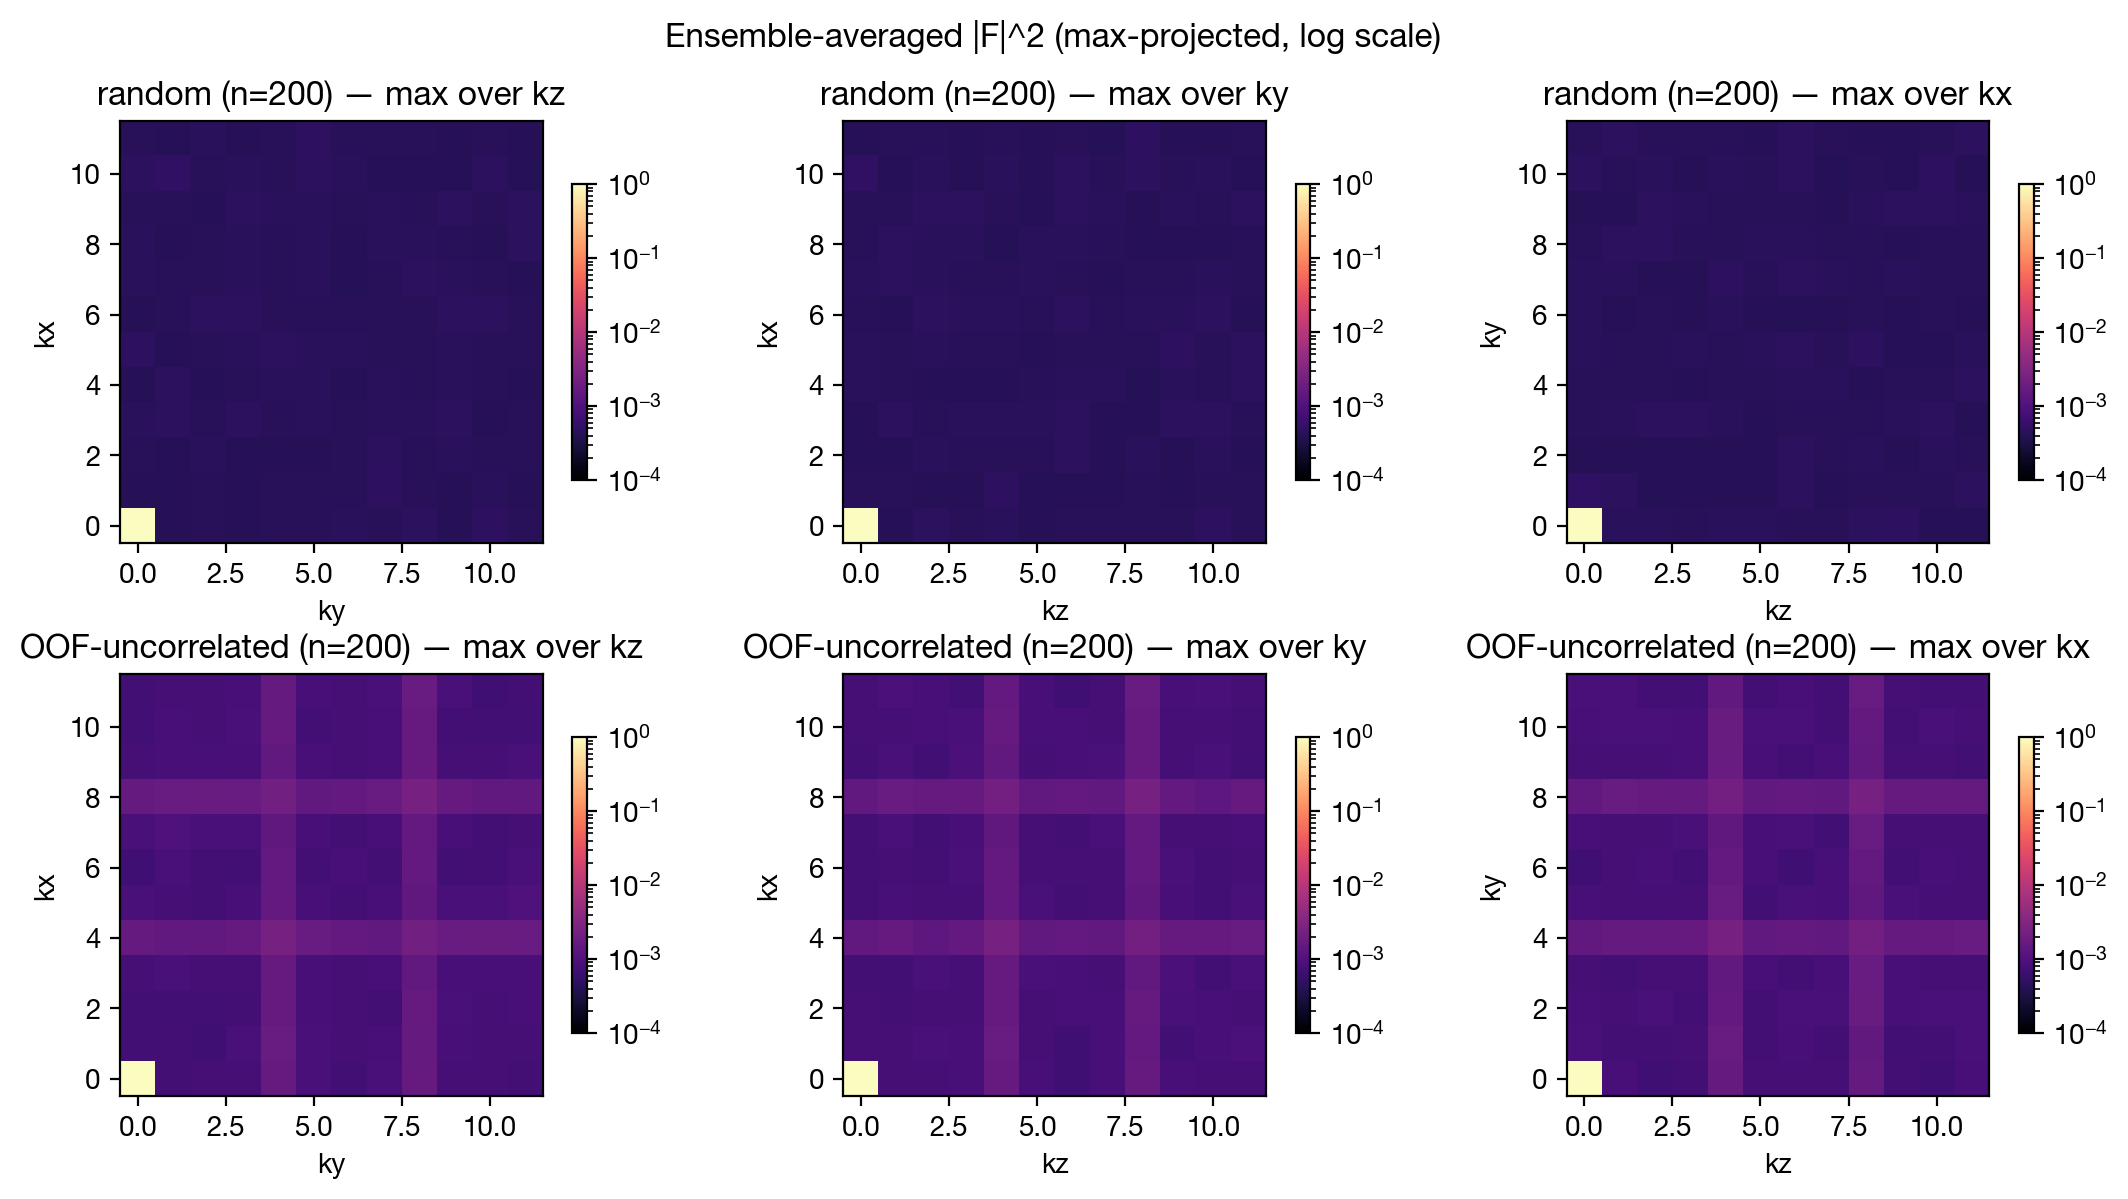

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
proj_names = [
    ("max over kz", "kx", "ky"),
    ("max over ky", "kx", "kz"),
    ("max over kx", "ky", "kz"),
]
ensemble_norm = LogNorm(vmin=1e-4, vmax=1, clip=True)
for i, (name, mean_sf) in enumerate(zip(["random", "OOF-uncorrelated"],
                                         [random_mean, oof_uncorrelated_mean])):
    projections = [mean_sf.max(axis=2), mean_sf.max(axis=1), mean_sf.max(axis=0)]
    for j, (proj_label, x_label, y_label) in enumerate(proj_names):
        ax = axes[i, j]
        im = ax.imshow(projections[j], origin="lower", cmap="magma", norm=ensemble_norm)
        ax.set_title(f"{name} (n={n_realisations}) — {proj_label}")
        ax.set_xlabel(y_label)
        ax.set_ylabel(x_label)
        fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("Ensemble-averaged |F|^2 (max-projected, log scale)")
fig.tight_layout()
plt.show()


Contrasting these panels with the single-configuration ones earlier:

**random** (averaged): the DC peak at `(0, 0)` is unchanged, and
the rest of the canvas is now a **uniform, featureless background**
at the expected noise floor.

**OOF-uncorrelated** (averaged): the rod geometry is now visible as a
clean multi-tier brightness hierarchy. Look at the `max over kz`
panel:

- brightest: DC at `(0, 0)`.
- next: **rod intersections** at `(4, 4), (4, 8), (8, 4), (8, 8)` —
  points where two sublattices' rods both pass through, so both
  contribute to `|F|^2`.
- middle: **rod footprints** — rows at `kx = 4, 8` (x-sublattice)
  and `ky = 4, 8` (y-sublattice), where only one sublattice
  contributes.
- background: every remaining pixel at a uniform noise floor. This
  isn't the raw `|F|^2` showing at those wavevectors — in 3D
  k-space, off-every-rod positions are **exactly zero**. The
  background comes from the max projection: at each `(kx, ky)`
  the projection picks up the brightest `|F|^2` found *anywhere*
  along the collapsed `kz` axis, which includes the z-sublattice
  rod at `kz = 4, 8`. The z-rod's intensity therefore "leaks" into
  every 2D pixel. The same effect explains the uniform background
  in the other two projections via the respectively collapsed rod.
